# 08 — CryNet Architecture from Scratch
## Building Every Component with Mathematical Justification

---

Architecture: CNN-BiLSTM-Attention Hybrid (~850K parameters)

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from src.utils import set_plot_style
set_plot_style()

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print("Device:", device)
print("PyTorch version:", torch.__version__)

Device: mps
PyTorch version: 2.8.0


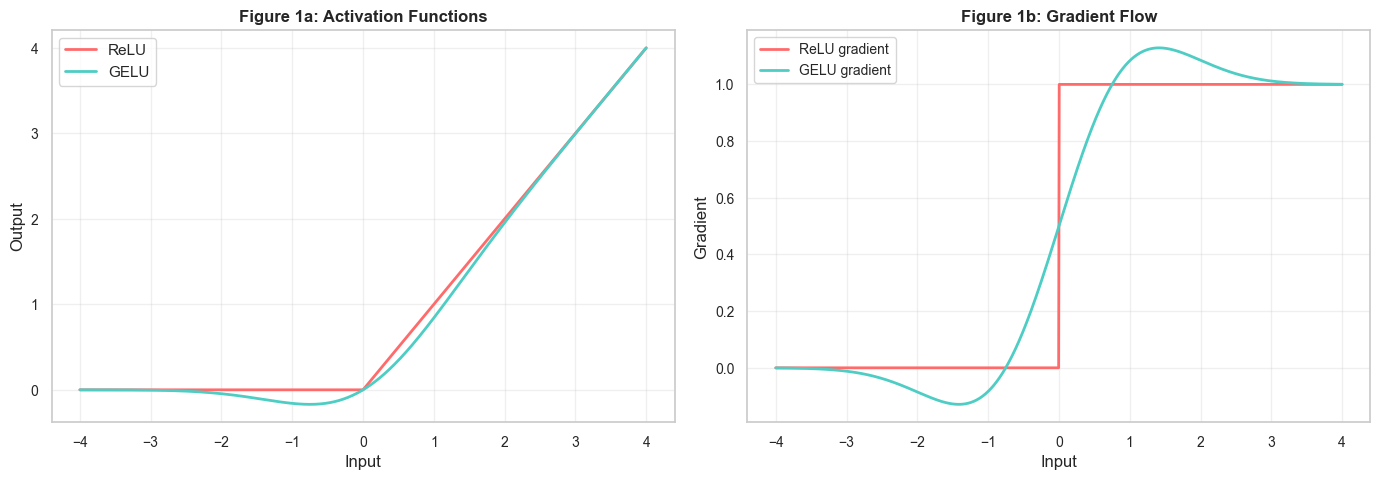

GELU avoids the dead neuron problem of ReLU


In [2]:
# ============================================================
# Figure 1: GELU vs ReLU Activation Functions
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.linspace(-4, 4, 1000)

relu = np.maximum(0, x)
gelu_vals = []
for v in x:
    gelu_vals.append(float(v * 0.5 * (1 + torch.erf(torch.tensor(v / np.sqrt(2))))))
gelu = np.array(gelu_vals)

ax1.plot(x, relu, label='ReLU', linewidth=2, color='#FF6B6B')
ax1.plot(x, gelu, label='GELU', linewidth=2, color='#4ECDC4')
ax1.set_title('Figure 1a: Activation Functions', fontsize=12, fontweight='bold')
ax1.set_xlabel('Input')
ax1.set_ylabel('Output')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

relu_grad = np.where(x > 0, 1.0, 0.0)
gelu_grad = np.gradient(gelu, x)
ax2.plot(x, relu_grad, label="ReLU gradient", linewidth=2, color='#FF6B6B')
ax2.plot(x, gelu_grad, label="GELU gradient", linewidth=2, color='#4ECDC4')
ax2.set_title('Figure 1b: Gradient Flow', fontsize=12, fontweight='bold')
ax2.set_xlabel('Input')
ax2.set_ylabel('Gradient')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("GELU avoids the dead neuron problem of ReLU")

In [3]:
# ============================================================
# Build and inspect CryNet
# ============================================================
from src.dl_model import CryNet, ConvBlock, SqueezeExcitationBlock, MultiHeadSelfAttention

model = CryNet(n_classes=8, n_mels=128, dropout=0.3)
total, trainable = model.count_parameters()
print("CryNet Architecture Summary")
print("=" * 60)
print(model)
print("=" * 60)
print("Total parameters:", f"{total:,}")
print("Trainable parameters:", f"{trainable:,}")

CryNet Architecture Summary
CryNet(
  (conv1): ConvBlock(
    (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): GELU(approximate='none')
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): ConvBlock(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): GELU(approximate='none')
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (se_block): SqueezeExcitationBlock(
    (squeeze): AdaptiveAvgPool2d(output_size=1)
    (excitation): Sequential(
      (0): Linear(in_features=64, out_features=16, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=16, out_features=64, bias=False)
      (3): Sigmoid()


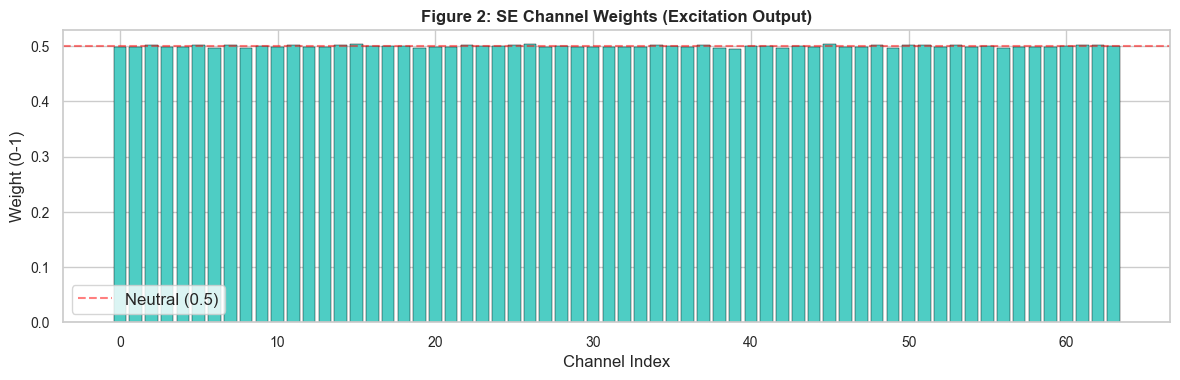

In [4]:
# ============================================================
# Figure 2: SE Block Channel Weights
# ============================================================

se_block = SqueezeExcitationBlock(channels=64, reduction=4)
dummy_conv_out = torch.randn(1, 64, 32, 47)
se_output = se_block(dummy_conv_out)

with torch.no_grad():
    z = se_block.squeeze(dummy_conv_out).view(1, 64)
    s = se_block.excitation(z).view(64).numpy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(64), s, color='#4ECDC4', edgecolor='black', linewidth=0.3)
ax.set_title('Figure 2: SE Channel Weights (Excitation Output)', fontsize=12, fontweight='bold')
ax.set_xlabel('Channel Index')
ax.set_ylabel('Weight (0-1)')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Neutral (0.5)')
ax.legend()
plt.tight_layout()
plt.show()

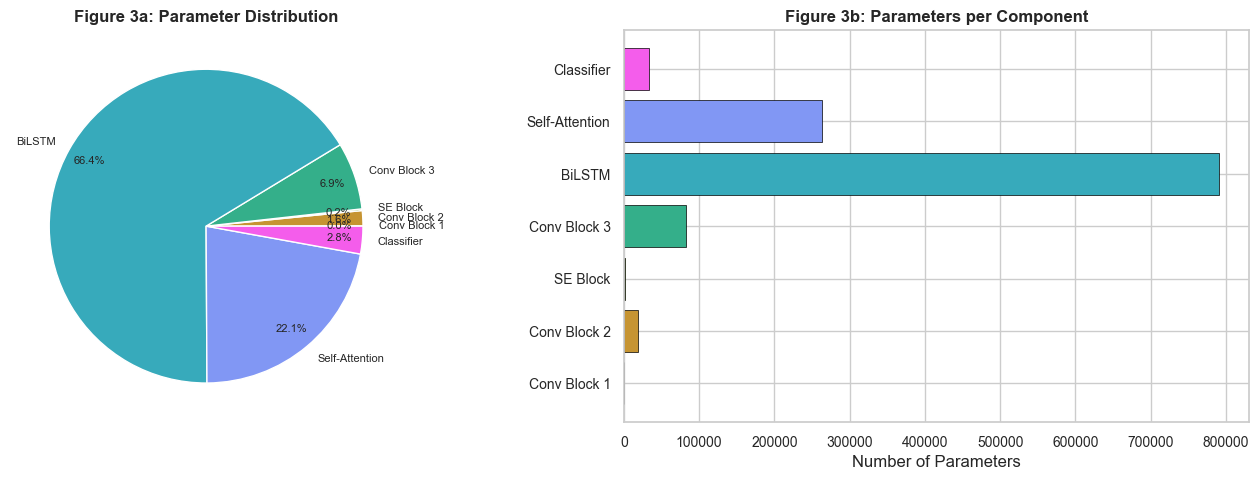

In [5]:
# ============================================================
# Figure 3: Parameter Distribution
# ============================================================

component_params = {
    'Conv Block 1': sum(p.numel() for p in model.conv1.parameters()),
    'Conv Block 2': sum(p.numel() for p in model.conv2.parameters()),
    'SE Block': sum(p.numel() for p in model.se_block.parameters()),
    'Conv Block 3': sum(p.numel() for p in model.conv3.parameters()),
    'BiLSTM': sum(p.numel() for p in model.bilstm.parameters()),
    'Self-Attention': sum(p.numel() for p in model.self_attention.parameters()),
    'Classifier': sum(p.numel() for p in model.classifier.parameters()),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('husl', len(component_params))
ax1.pie(component_params.values(), labels=component_params.keys(),
        autopct='%1.1f%%', colors=colors, pctdistance=0.85, textprops={'fontsize': 8})
ax1.set_title('Figure 3a: Parameter Distribution', fontsize=12, fontweight='bold')

bars = ax2.barh(list(component_params.keys()), list(component_params.values()),
                 color=colors, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Number of Parameters')
ax2.set_title('Figure 3b: Parameters per Component', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Verify Forward Pass
# ============================================================

model.eval()
with torch.no_grad():
    dummy_batch = torch.randn(4, 1, 128, 188)
    output = model(dummy_batch)
    probs = F.softmax(output, dim=1)

print("End-to-End Forward Pass Verification:")
print("  Input: ", dummy_batch.shape)
print("  Output:", output.shape)
print("  Probs sum to 1:", probs.sum(dim=1).allclose(torch.ones(4)))

embeddings = model.get_embeddings(dummy_batch)
print("  Embeddings shape:", embeddings.shape)

print("\nAll components verified. Next: 09_training_deep_learning.ipynb")

End-to-End Forward Pass Verification:
  Input:  torch.Size([4, 1, 128, 188])
  Output: torch.Size([4, 8])
  Probs sum to 1: True
  Embeddings shape: torch.Size([4, 256])

All components verified. Next: 09_training_deep_learning.ipynb
